# SenPa-MAE Test

In [1]:
import sys
import os
import torch
import numpy as np
from pathlib import Path

# Set up paths
os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

# Import necessary modules
import hydra
from omegaconf import OmegaConf
from hydra.core.global_hydra import GlobalHydra
from hydra import initialize, compose
from geofm_src.factory import create_dataset, create_model, model_registry, dataset_registry

# Initialize Hydra
# Clear any previous initialization
GlobalHydra.instance().clear()
# Initialize with the correct config path
initialize(config_path="../geofm_src/configs/", caller_stack_depth=2)

# Print available models in the registry
print("Available models in the registry:")
for model_name in model_registry.keys():
    print(f"- {model_name}")

# Print available datasets in the registry
print("\nAvailable datasets in the registry:")
for dataset_name in dataset_registry.keys():
    print(f"- {dataset_name}")

Adding /home/ando to sys.path


/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Available models in the registry:
- croma
- dinov2
- softcon
- dofa
- senpamae
- panopticon
- galileo
- anysat

Available datasets in the registry:
- geobench
- resisc45
- benv2
- corine
- digital_typhoon
- tropical_cyclone
- hyperview
- fmow
- dummy


/data/tmp/ipykernel_74485/2916192492.py:31: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../geofm_src/configs/", caller_stack_depth=2)


In [12]:
# Function to create a dummy dataset config
def create_dummy_dataset_config(num_channels=4, image_resolution=224, num_classes=19, task="classification", senpamae_channels=[0,1,2,3]):
    """Create a dummy dataset config for testing."""
    config = {
        "dataset_type": "dummy",
        "num_channels": num_channels,
        "image_resolution": image_resolution,
        "num_classes": num_classes,
        "task": task,
        "band_gsds": [10.0] * (num_channels),  # Ground sample distance for each band
        "senpamae_channels": senpamae_channels,  # For SenPaMAE model
        "senpamae_srf_name": "rfs_sentinel2_a_13b.npy"  # For SenPaMAE model
    }
    return OmegaConf.create(config)

# Function to load a model config
def load_model_config(model_name):
    """Load a model config from the configs directory."""
    try:
        # Try to load the model config using Hydra
        model_config = compose(config_name=f"{model_name}")
        return model_config
    except Exception as e:
        print(f"Error loading model config: {e}")
        # Create a basic model config if loading fails
        config = {
            "model_type": 'galileo',
            "embed_dim": 768,
            "image_resolution": 64,
            "pretrained_path": '/data/panopticon/other_model_ckpts/galileo/encoder.pt',
            "patch_size": 12,
            "segm_blk_indices": [3, 5, 7, 11],
            "accel_cls_blk_indices": [8, 9, 10, 11],
            "default_cls_blk_indices": [11],
            "input_key": "s2"
        }
        return OmegaConf.create(config)
    
# Function to instantiate and test a model
def test_model(model_name, dataset_config=None):
    """Instantiate a model and run a forward pass with dummy data."""
    print(f"\n--- Testing {model_name} model ---")
    
    # Load model config
    model_config = load_model_config(model_name)
    model_config.model_type = model_name
    
    # Adjust model config to match dataset
    # if dataset_config:
    #     model_config.num_channels = dataset_config.num_channels
    #     model_config.image_resolution = dataset_config.image_resolution
    
    print(f"Model config:")
    print(OmegaConf.to_yaml(model_config))
    
    # try:
        # Create model
    model = create_model(model_config, dataset_config)
    print(f"Successfully created {model_name} model")
    
    # Create dummy input
    batch_size = 5
    channels = dataset_config.num_channels
    resolution = dataset_config.image_resolution
    dummy_input = torch.rand(batch_size, channels, resolution, resolution)

    print(f"Dummy input shape: {dummy_input.shape}")
    
    # Get blocks (features)
    model.load_encoder(model_config.default_cls_blk_indices)
    blocks = model.get_blocks(dummy_input)
    print(f"Extracted {len(blocks)} feature blocks")
    
    # Get feature vector
    features = model.default_blocks_to_featurevec(blocks)
    print(f"Feature vector shape: {features.shape}")
    
    return model, features
    
    # except Exception as e:
    #     print(f"Error instantiating or running {model_name} model: {e}")
    #     return None, None

In [13]:
dummy_dataset_config = create_dummy_dataset_config(num_channels=10, image_resolution=120, senpamae_channels=[0,1,2,3,4,5,6,7])
print("\nDummy dataset config:")
print(OmegaConf.to_yaml(dummy_dataset_config))


Dummy dataset config:
dataset_type: dummy
num_channels: 10
image_resolution: 120
num_classes: 19
task: classification
band_gsds:
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
senpamae_channels:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
- 7
senpamae_srf_name: rfs_sentinel2_a_13b.npy



In [14]:
# Test a specific model (e.g., SenPaMAE)
model_name = "galileo"  # Change this to test different models
model, features = test_model(model_name, dummy_dataset_config)



--- Testing galileo model ---
Error loading model config: Primary config directory not found.
Check that the config directory '/home/ando/.conda/envs/fm/lib/python3.10/site-packages/IPython/geofm_src/configs' exists and readable
Model config:
model_type: galileo
embed_dim: 768
image_resolution: 64
pretrained_path: /data/panopticon/other_model_ckpts/galileo/encoder.pt
patch_size: 12
segm_blk_indices:
- 3
- 5
- 7
- 11
accel_cls_blk_indices:
- 8
- 9
- 10
- 11
default_cls_blk_indices:
- 11
input_key: s2

Successfully created galileo model
Dummy input shape: torch.Size([5, 10, 120, 120])
PRETRAINED PATH: /data/panopticon/other_model_ckpts/galileo/encoder.pt
dict_keys(['training', 'model', 'run_name', 'wandb_run_id', 'beaker_workload_id', 'beaker_node_hostname', 'beaker_experiment_url', 'cur_epoch'])
{'training': {'patch_sizes': [1, 2, 3, 4, 5, 6, 7, 8], 'conditioner_mode': 'no_cond', 'max_lr': 0.0001, 'num_epochs': 500, 'batch_size': 32, 'effective_batch_size': 512, 'warmup_epochs': 30, 'f

In [5]:
model

GalileoWrapper(
  (encoder): Encoder(
    (blocks): ModuleListWithInit(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=768, out_features=768, bias=True)
          (k): Linear(in_features=768, out_features=768, bias=True)
          (v): Linear(in_features=768, out_features=768, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path): DropPath()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
          (fc2): Linear(in_features=3072

# Corine-MODIS

In [23]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/corine_modis.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print(ds_cfg)

[ClsDataAugmentation: train] Sampling channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
[ClsDataAugmentation: val/test] Sampling channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 16, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 128, 'multilabel': True, 'full_spectra': True, 'target_dataset_name': 'dummy-modis', 'band_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'senpamae_channels': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'band_gsds': [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30], 'senpamae_srf_name': 'rfs_modis_terra.npy', 'wavelengths_mean_nm': [418, 424, 429, 434, 439, 444, 449, 454, 459, 463, 468, 473, 477, 482, 487, 491, 496], 'wavelengths_mean_microns': [0.418, 0.424, 0.429, 0.434, 0.439, 0.444, 0.449, 

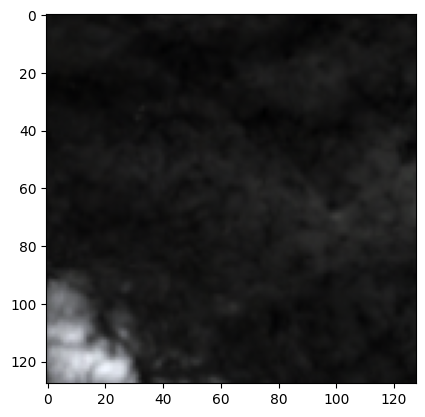

In [21]:
import random   

sample, label = train_ds[random.randint(0, len(train_ds))]
sample.shape, label.shape


import matplotlib.pyplot as plt

rgb = [7,6,3]
img = sample[rgb].permute(1,2,0).cpu().numpy()
img = (img - img.min())/(img.max() - img.min())

plt.imshow(img)
plt.show()




